# KAN Hyperparameter Sweep + Real Data Benchmark

1. **Part 1**: Hyperparameter sweep on synthetic data
2. **Part 2**: Apply best settings to real data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


## Part 1: Hyperparameter Sweep (Synthetic Data)

In [2]:
# Load synthetic dataset
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
X = df.drop('Injury_Risk', axis=1).values
y = df['Injury_Risk'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
n_features = X_train_scaled.shape[1]
print(f"Synthetic: {n_features} features, {len(X_train)} train samples")

Synthetic: 15 features, 420 train samples

In [3]:
# ChebyKAN implementation
class ChebyKANLayer(nn.Module):
    def __init__(self, in_f, out_f, degree=5):
        super().__init__()
        self.degree = degree
        self.coeffs = nn.Parameter(torch.randn(in_f, out_f, degree + 1) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_f))
    
    def forward(self, x):
        x_norm = torch.tanh(x)
        T = [torch.ones_like(x_norm), x_norm]
        for _ in range(2, self.degree + 1):
            T.append(2 * x_norm * T[-1] - T[-2])
        T = torch.stack(T, dim=-1)
        return torch.einsum('bid,iod->bo', T, self.coeffs) + self.bias

class ChebyKAN(nn.Module):
    def __init__(self, dims, degree=5):
        super().__init__()
        self.layers = nn.ModuleList([ChebyKANLayer(dims[i], dims[i+1], degree) for i in range(len(dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

def train_eval(model, train_loader, X_test_t, y_test, epochs=200, lr=0.003):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCELoss()
    
    start = time.time()
    for _ in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
    train_time = time.time() - start
    
    model.eval()
    with torch.no_grad():
        y_prob = model(X_test_t.to(device)).cpu().numpy().flatten()
    y_pred = (y_prob > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    return acc, f1, auc, train_time

In [4]:
# Hyperparameter sweep
print("=" * 60)
print("HYPERPARAMETER SWEEP - ChebyKAN")
print("=" * 60)

configs = [
    # (architecture, degree, lr, epochs, name)
    ([n_features, 64, 32, 1], 4, 0.003, 200, "Shallow, deg4"),
    ([n_features, 64, 32, 1], 5, 0.003, 200, "Shallow, deg5"),
    ([n_features, 64, 32, 1], 6, 0.003, 200, "Shallow, deg6"),
    ([n_features, 128, 64, 32, 1], 5, 0.002, 250, "Deep, deg5"),
    ([n_features, 128, 64, 32, 1], 6, 0.002, 250, "Deep, deg6"),
    ([n_features, 100, 50, 1], 5, 0.003, 300, "Wide, deg5"),
    ([n_features, 100, 50, 1], 6, 0.003, 300, "Wide, deg6"),
]

sweep_results = []
for arch, deg, lr, epochs, name in configs:
    print(f"Testing: {name}...", end=" ")
    model = ChebyKAN(arch, degree=deg)
    acc, f1, auc, t = train_eval(model, train_loader, X_test_t, y_test, epochs=epochs, lr=lr)
    sweep_results.append({'Config': name, 'Arch': str(arch), 'Degree': deg, 'Acc': acc, 'F1': f1, 'AUC': auc, 'Time': t})
    print(f"Acc={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")

sweep_df = pd.DataFrame(sweep_results).sort_values('Acc', ascending=False)
print("\n" + "=" * 60)
print("SWEEP RESULTS")
print("=" * 60)
display(sweep_df.round(4))

best_config = sweep_df.iloc[0]
print(f"\n🏆 Best: {best_config['Config']} with Acc={best_config['Acc']:.4f}")

HYPERPARAMETER SWEEP - ChebyKAN
Testing: Shallow, deg4... 

Acc=0.8444, F1=0.7083, AUC=0.8456
Testing: Shallow, deg5... 

Acc=0.7556, F1=0.4211, AUC=0.8036
Testing: Shallow, deg6... 

Acc=0.7333, F1=0.3333, AUC=0.7535
Testing: Deep, deg5... 

Acc=0.7667, F1=0.5882, AUC=0.7385
Testing: Deep, deg6... 

Acc=0.7333, F1=0.4286, AUC=0.7200
Testing: Wide, deg5... 

Acc=0.8000, F1=0.5909, AUC=0.8485
Testing: Wide, deg6... 

Acc=0.7889, F1=0.5581, AUC=0.7921

SWEEP RESULTS


,Config,Arch,Degree,Acc,F1,AUC,Time
0,"Shallow, deg4","[15, 64, 32, 1]",4,0.8444,0.7083,0.8456,19.4762
5,"Wide, deg5","[15, 100, 50, 1]",5,0.8000,0.5909,0.8485,27.9883
6,"Wide, deg6","[15, 100, 50, 1]",6,0.7889,0.5581,0.7921,30.6989
3,"Deep, deg5","[15, 128, 64, 32, 1]",5,0.7667,0.5882,0.7385,26.4793
1,"Shallow, deg5","[15, 64, 32, 1]",5,0.7556,0.4211,0.8036,17.8205
2,"Shallow, deg6","[15, 64, 32, 1]",6,0.7333,0.3333,0.7535,18.3699
4,"Deep, deg6","[15, 128, 64, 32, 1]",6,0.7333,0.4286,0.7200,25.0677



🏆 Best: Shallow, deg4 with Acc=0.8444


## Part 2: Real Data with Best Settings

In [5]:
# Load and preprocess real dataset
df_real = pd.read_csv('../data/player_injuries_impact.csv')

def parse_rating(r):
    if pd.isna(r) or r == 'N.A.': 
        return np.nan
    try:
        return float(str(r).replace('(S)', '').strip())
    except:
        return np.nan

def result_to_pts(r):
    if pd.isna(r) or r == 'N.A.': return np.nan
    r = str(r).lower()
    return 3 if r == 'win' else (1 if r == 'draw' else 0)

# Feature engineering
for i in [1,2,3]:
    df_real[f'rating_before_{i}'] = df_real[f'Match{i}_before_injury_Player_rating'].apply(parse_rating)
    df_real[f'rating_after_{i}'] = df_real[f'Match{i}_after_injury_Player_rating'].apply(parse_rating)
    df_real[f'pts_before_{i}'] = df_real[f'Match{i}_before_injury_Result'].apply(result_to_pts)
    df_real[f'pts_after_{i}'] = df_real[f'Match{i}_after_injury_Result'].apply(result_to_pts)

df_real['avg_rating_before'] = df_real[[f'rating_before_{i}' for i in [1,2,3]]].mean(axis=1)
df_real['avg_rating_after'] = df_real[[f'rating_after_{i}' for i in [1,2,3]]].mean(axis=1)
df_real['target'] = (df_real['avg_rating_after'] >= df_real['avg_rating_before']).astype(int)

df_clean = df_real.dropna(subset=['target', 'avg_rating_before', 'avg_rating_after'])

# Encode categoricals
df_clean['Position_enc'] = LabelEncoder().fit_transform(df_clean['Position'])
df_clean['Team_enc'] = LabelEncoder().fit_transform(df_clean['Team Name'])
df_clean['Injury_enc'] = LabelEncoder().fit_transform(df_clean['Injury'].str.lower())

feature_cols = ['Age', 'FIFA rating', 'Position_enc', 'Team_enc', 'Injury_enc', 'avg_rating_before']
X_real = df_clean[feature_cols].values
y_real = df_clean['target'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

X_train_r_t = torch.FloatTensor(X_train_r_scaled)
y_train_r_t = torch.FloatTensor(y_train_r).unsqueeze(1)
X_test_r_t = torch.FloatTensor(X_test_r_scaled)

train_loader_r = DataLoader(TensorDataset(X_train_r_t, y_train_r_t), batch_size=32, shuffle=True)
n_features_r = X_train_r_scaled.shape[1]
print(f"Real data: {len(df_clean)} samples, {n_features_r} features")

Real data: 503 samples, 6 features


In [6]:
# Run all models on real data
print("\n" + "=" * 60)
print("REAL DATA BENCHMARK (With Improved Settings)")
print("=" * 60)

real_results = []

# XGBoost baseline
start = time.time()
xgb_r = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
xgb_r.fit(X_train_r_scaled, y_train_r)
y_pred_xgb = xgb_r.predict(X_test_r_scaled)
y_prob_xgb = xgb_r.predict_proba(X_test_r_scaled)[:, 1]
acc_xgb = accuracy_score(y_test_r, y_pred_xgb)
real_results.append({'Model': 'XGBoost', 'Acc': acc_xgb, 'F1': f1_score(y_test_r, y_pred_xgb), 'AUC': roc_auc_score(y_test_r, y_prob_xgb)})
print(f"XGBoost: Acc={acc_xgb:.4f}")

# MLP
class MLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

mlp_r = MLP(n_features_r)
acc, f1, auc, _ = train_eval(mlp_r, train_loader_r, X_test_r_t, y_test_r, epochs=200)
real_results.append({'Model': 'MLP', 'Acc': acc, 'F1': f1, 'AUC': auc})
print(f"MLP: Acc={acc:.4f}")

# ChebyKAN with different configs
for arch, deg, name in [
    ([n_features_r, 64, 32, 1], 5, "ChebyKAN (deg5)"),
    ([n_features_r, 64, 32, 1], 6, "ChebyKAN (deg6)"),
    ([n_features_r, 100, 50, 1], 5, "ChebyKAN (wide)"),
]:
    model = ChebyKAN(arch, degree=deg)
    acc, f1, auc, _ = train_eval(model, train_loader_r, X_test_r_t, y_test_r, epochs=250, lr=0.002)
    real_results.append({'Model': name, 'Acc': acc, 'F1': f1, 'AUC': auc})
    print(f"{name}: Acc={acc:.4f}")

real_df = pd.DataFrame(real_results).sort_values('Acc', ascending=False)
print("\n" + "=" * 60)
display(real_df.round(4))


REAL DATA BENCHMARK (With Improved Settings)


XGBoost: Acc=0.6931


MLP: Acc=0.6931


ChebyKAN (deg5): Acc=0.6634


ChebyKAN (deg6): Acc=0.6832


ChebyKAN (wide): Acc=0.7426



,Model,Acc,F1,AUC
4,ChebyKAN (wide),0.7426,0.7347,0.8067
0,XGBoost,0.6931,0.6931,0.7380
1,MLP,0.6931,0.6869,0.7561
3,ChebyKAN (deg6),0.6832,0.6800,0.6863
2,ChebyKAN (deg5),0.6634,0.6600,0.7388


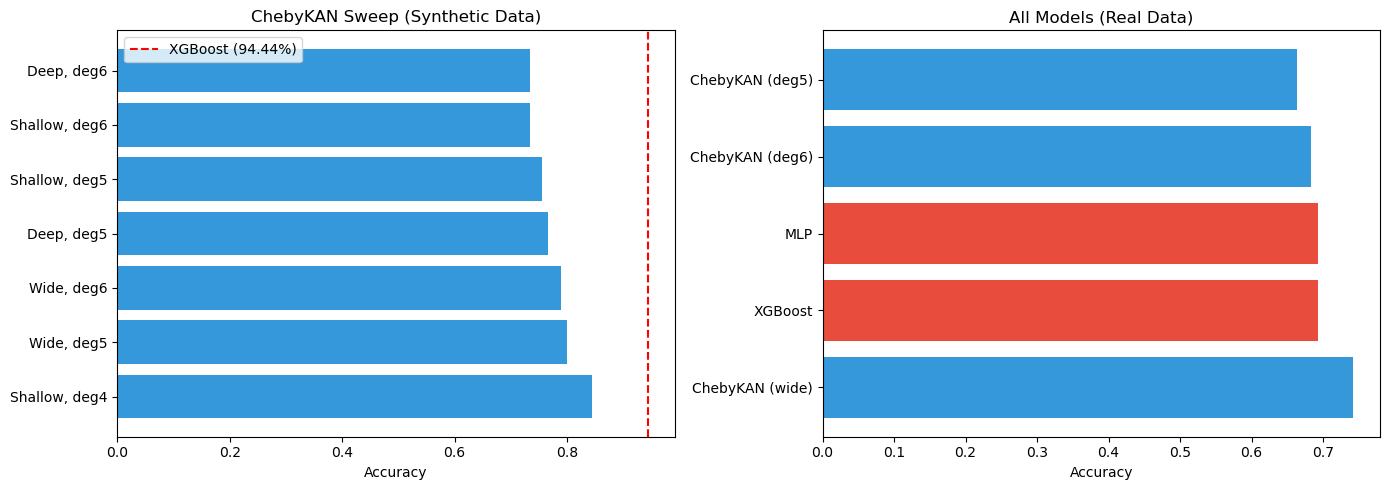


📊 Saved: figures/hyperparameter_sweep_results.png


In [7]:
# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Synthetic sweep results
ax1 = axes[0]
ax1.barh(sweep_df['Config'], sweep_df['Acc'], color='#3498db')
ax1.axvline(x=0.9444, color='red', linestyle='--', label='XGBoost (94.44%)')
ax1.set_xlabel('Accuracy')
ax1.set_title('ChebyKAN Sweep (Synthetic Data)')
ax1.legend()

# Real data results
ax2 = axes[1]
colors = ['#e74c3c' if 'XGB' in m or 'MLP' in m else '#3498db' for m in real_df['Model']]
ax2.barh(real_df['Model'], real_df['Acc'], color=colors)
ax2.set_xlabel('Accuracy')
ax2.set_title('All Models (Real Data)')

plt.tight_layout()
plt.savefig('../figures/hyperparameter_sweep_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Saved: figures/hyperparameter_sweep_results.png")

In [8]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("\n📈 SYNTHETIC DATA:")
print(f"   Best ChebyKAN: {sweep_df.iloc[0]['Config']} with {sweep_df.iloc[0]['Acc']:.4f}")
print(f"   XGBoost baseline: 0.9444")
print(f"   Gap: {sweep_df.iloc[0]['Acc'] - 0.9444:+.4f}")

print("\n📈 REAL DATA:")
best_real = real_df.iloc[0]
xgb_real = real_df[real_df['Model']=='XGBoost']['Acc'].values[0]
best_kan_real = real_df[real_df['Model'].str.contains('Cheby')].iloc[0] if len(real_df[real_df['Model'].str.contains('Cheby')]) > 0 else None
print(f"   Best overall: {best_real['Model']} with {best_real['Acc']:.4f}")
if best_kan_real is not None:
    print(f"   Best ChebyKAN: {best_kan_real['Model']} with {best_kan_real['Acc']:.4f}")
    print(f"   Gap to XGBoost: {best_kan_real['Acc'] - xgb_real:+.4f}")


FINAL SUMMARY

📈 SYNTHETIC DATA:
   Best ChebyKAN: Shallow, deg4 with 0.8444
   XGBoost baseline: 0.9444
   Gap: -0.1000

📈 REAL DATA:
   Best overall: ChebyKAN (wide) with 0.7426
   Best ChebyKAN: ChebyKAN (wide) with 0.7426
   Gap to XGBoost: +0.0495
